# Student Performance Prediction System

Capstone Project — analyzing student academic data to predict performance outcomes and generate improvement recommendations.

**Dataset:** StudentPerformanceFactors.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Module 1: Data Collection & Preprocessing

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'StudentPerformanceFactors.csv'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


**Duplicate records**

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


**Missing values**

In [ ]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [ ]:
# Teacher_Quality, Parental_Education_Level and Distance_from_Home have a small number
# of missing entries. Since these are categorical, dropping the rows would waste usable
# data, so we fill them with the most frequent value (mode) instead.
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

np.int64(0)

We keep a clean, human-readable copy of the dataframe for the EDA section before any encoding happens.

In [ ]:
df_eda = df.copy()

**Encoding categorical data**

Most of the categorical columns here are ordinal (Low/Medium/High etc.), so we map them to ordered integers instead of one-hot encoding, which keeps the "low < medium < high" relationship intact for the models.

In [ ]:
ordinal_map = {"Low": 0, "Medium": 1, "High": 2}
for col in ["Parental_Involvement", "Access_to_Resources", "Motivation_Level",
            "Family_Income", "Teacher_Quality"]:
    df[col] = df[col].map(ordinal_map)

df["Parental_Education_Level"] = df["Parental_Education_Level"].map(
    {"High School": 0, "College": 1, "Postgraduate": 2})

df["Distance_from_Home"] = df["Distance_from_Home"].map(
    {"Near": 0, "Moderate": 1, "Far": 2})

df["Peer_Influence"] = df["Peer_Influence"].map(
    {"Negative": 0, "Neutral": 1, "Positive": 2})

binary_map = {"Yes": 1, "No": 0}
for col in ["Extracurricular_Activities", "Internet_Access", "Learning_Disabilities"]:
    df[col] = df[col].map(binary_map)

df["School_Type"] = df["School_Type"].map({"Public": 0, "Private": 1})
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,0,7,73,0,1,0,0,1,0,2,3,0,0,0,0,67
1,19,64,0,1,0,8,59,0,1,2,1,1,0,0,4,0,1,1,1,61
2,24,98,1,1,1,7,91,1,1,2,1,1,0,1,4,0,2,0,0,74
3,29,89,0,1,1,8,98,1,1,1,1,1,0,0,4,0,0,1,0,71
4,19,92,1,1,1,6,65,1,1,3,1,2,0,1,4,0,1,0,1,70


In [ ]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement          int64
Access_to_Resources           int64
Extracurricular_Activities    int64
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level              int64
Internet_Access               int64
Tutoring_Sessions             int64
Family_Income                 int64
Teacher_Quality               int64
School_Type                   int64
Peer_Influence                int64
Physical_Activity             int64
Learning_Disabilities         int64
Parental_Education_Level      int64
Distance_from_Home            int64
Gender                        int64
Exam_Score                    int64
dtype: object

**Normalizing features**

The numeric features are on very different scales (e.g. Sleep_Hours is 4-10, Attendance is 60-100), which matters for distance/gradient based models like Linear Regression. We scale a copy of the feature set and keep the original unscaled version too, since tree-based models don't need scaling and it's easier to read feature importances in the original units.

In [ ]:
numeric_cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
                 "Tutoring_Sessions", "Physical_Activity"]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df_scaled.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.504942,0.348375,0,2,0,-0.019796,-0.143800,0,1,-1.213934,0,1,0,2,0.031411,0,0,0,0,67
1,-0.162822,-1.383736,0,1,0,0.661399,-1.116110,0,1,0.411451,1,1,0,0,1.001199,0,1,1,1,61
2,0.671882,1.560853,1,1,1,-0.019796,1.106313,1,1,0.411451,1,1,0,1,1.001199,0,2,0,0,74
3,1.506587,0.781403,0,1,1,0.661399,1.592469,1,1,-0.401242,1,1,0,0,1.001199,0,0,1,0,71
4,-0.162822,1.041220,1,1,1,-0.700990,-0.699406,1,1,1.224144,1,2,0,1,1.001199,0,1,0,1,70


## Module 2: Exploratory Data Analysis

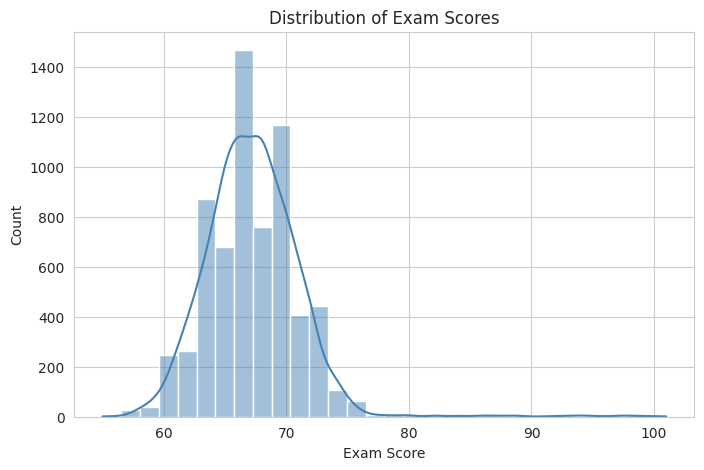

In [ ]:
plt.figure()
sns.histplot(df_eda["Exam_Score"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.show()

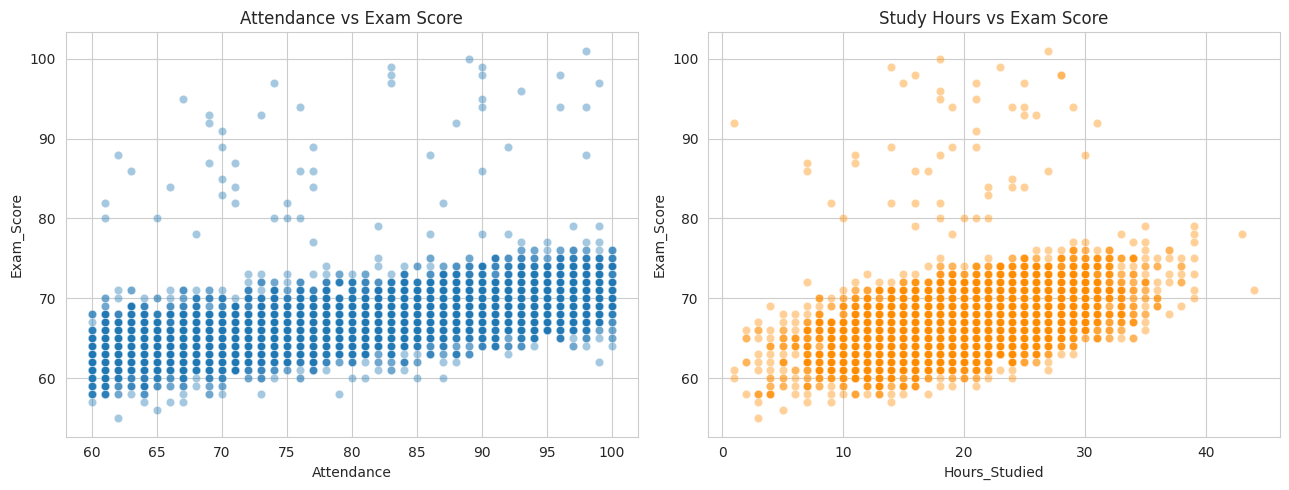

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df_eda, x="Attendance", y="Exam_Score", alpha=0.4, ax=axes[0])
axes[0].set_title("Attendance vs Exam Score")

sns.scatterplot(data=df_eda, x="Hours_Studied", y="Exam_Score", alpha=0.4, ax=axes[1], color="darkorange")
axes[1].set_title("Study Hours vs Exam Score")

plt.tight_layout()
plt.show()

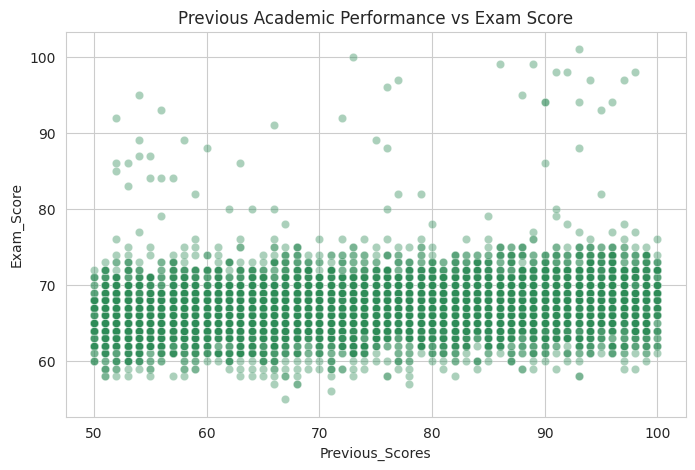

In [ ]:
plt.figure()
sns.scatterplot(data=df_eda, x="Previous_Scores", y="Exam_Score", alpha=0.4, color="seagreen")
plt.title("Previous Academic Performance vs Exam Score")
plt.show()

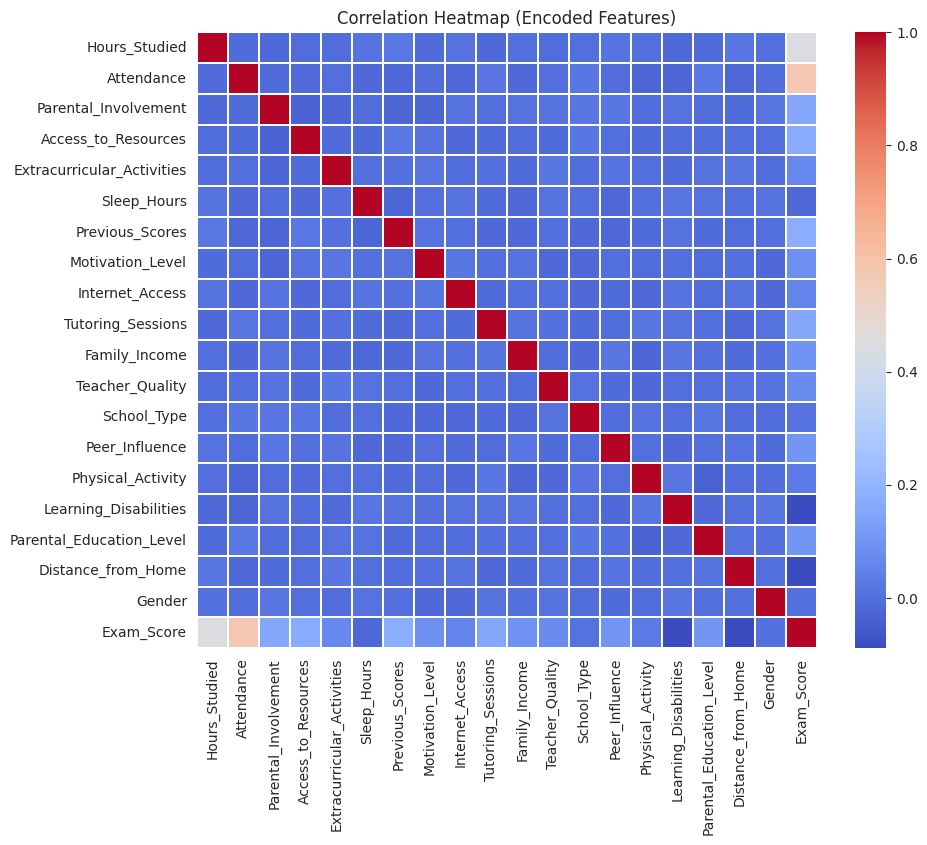

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.3)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

In [ ]:
corr["Exam_Score"].sort_values(ascending=False)

Exam_Score                    1.000000
Attendance                    0.581072
Hours_Studied                 0.445455
Previous_Scores               0.175079
Access_to_Resources           0.169770
Parental_Involvement          0.157114
Tutoring_Sessions             0.156525
Parental_Education_Level      0.103817
Peer_Influence                0.100217
Family_Income                 0.094555
Motivation_Level              0.086937
Teacher_Quality               0.076684
Extracurricular_Activities    0.064382
Internet_Access               0.051475
Physical_Activity             0.027824
School_Type                   0.008844
Gender                        0.002032
Sleep_Hours                  -0.017022
Learning_Disabilities        -0.085066
Distance_from_Home           -0.088934
Name: Exam_Score, dtype: float64

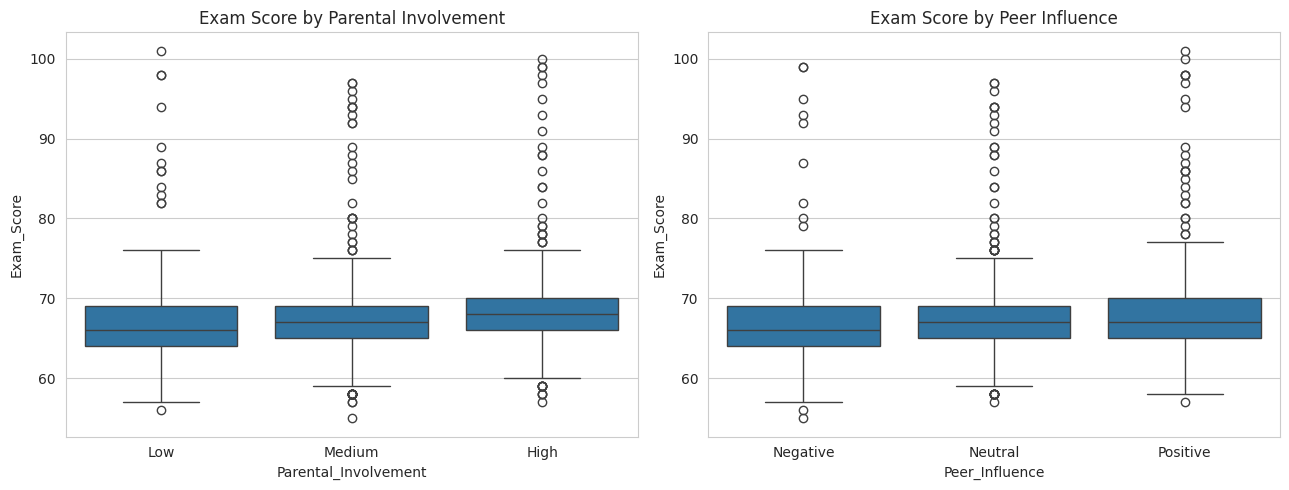

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_eda, x="Parental_Involvement", y="Exam_Score",
            order=["Low", "Medium", "High"], ax=axes[0])
axes[0].set_title("Exam Score by Parental Involvement")

sns.boxplot(data=df_eda, x="Peer_Influence", y="Exam_Score",
            order=["Negative", "Neutral", "Positive"], ax=axes[1])
axes[1].set_title("Exam Score by Peer Influence")

plt.tight_layout()
plt.show()

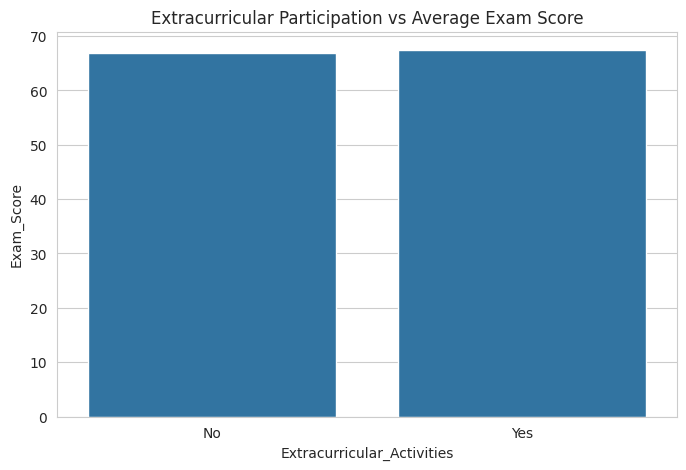

In [ ]:
plt.figure()
sns.barplot(data=df_eda, x="Extracurricular_Activities", y="Exam_Score", errorbar=None)
plt.title("Extracurricular Participation vs Average Exam Score")
plt.show()

**Quick takeaways from the EDA:**
- Attendance and previous academic performance show the strongest positive relationship with exam scores.
- Study hours also correlate positively, though with more spread than attendance.
- Students with higher parental involvement and more positive peer influence tend to score a bit higher on average, but the effect is smaller than attendance/study hours.
- The score distribution is fairly tight and roughly bell-shaped, with a handful of high-scoring outliers above 90.

## Module 3: Performance Prediction Model

We approach this in two parts, matching the objective of both predicting a **score** and a **performance level**:

1. **Regression** — predict the actual `Exam_Score`.
2. **Classification** — bucket students into `Low` / `Average` / `High` performance and predict that category.

In [ ]:
features = [c for c in df.columns if c not in ["Exam_Score"]]
X = df[features]
y_reg = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((5285, 19), (1322, 19))

**Regression models**

In [ ]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    reg_results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})

reg_results_df = pd.DataFrame(reg_results).sort_values("R2 Score", ascending=False)
reg_results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.444289,1.799429,0.770928
2,Random Forest,1.227956,2.242853,0.644120
1,Decision Tree,1.644932,2.676394,0.493240


Best regression model: Linear Regression


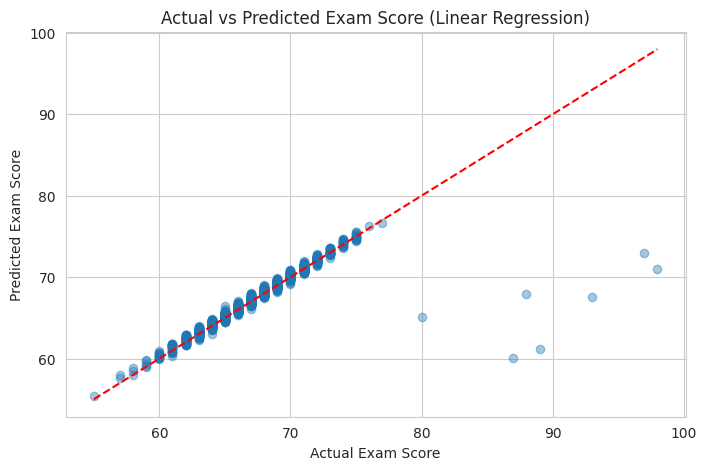

In [ ]:
best_reg_name = reg_results_df.iloc[0]["Model"]
best_reg_model = reg_models[best_reg_name]
print(f"Best regression model: {best_reg_name}")

preds = best_reg_model.predict(X_test)
plt.figure()
plt.scatter(y_test, preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title(f"Actual vs Predicted Exam Score ({best_reg_name})")
plt.show()

**Turning exam score into a performance level**

We split scores into three roughly equal-sized bands using tertiles so the classes aren't heavily imbalanced.

In [ ]:
df["Performance_Level"] = pd.qcut(df["Exam_Score"], q=3, labels=["Low", "Average", "High"])
df["Performance_Level"].value_counts()

Performance_Level
Low        2882
Average    2100
High       1625
Name: count, dtype: int64

**Classification models**

In [ ]:
y_clf = df["Performance_Level"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

clf_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
}

clf_results = []
fitted_clfs = {}
for name, model in clf_models.items():
    model.fit(X_train_c, y_train_c)
    preds = model.predict(X_test_c)
    acc = accuracy_score(y_test_c, preds)
    clf_results.append({"Model": name, "Accuracy": acc})
    fitted_clfs[name] = model

pd.DataFrame(clf_results).sort_values("Accuracy", ascending=False)

,Model,Accuracy
1,Random Forest,0.789713
0,Decision Tree,0.719365


In [ ]:
best_clf_name = max(clf_results, key=lambda r: r["Accuracy"])["Model"]
best_clf = fitted_clfs[best_clf_name]
preds = best_clf.predict(X_test_c)

print(f"Best classifier: {best_clf_name}\n")
print(classification_report(y_test_c, preds))

Best classifier: Random Forest

              precision    recall  f1-score   support

     Average       0.68      0.66      0.67       420
        High       0.85      0.76      0.80       325
         Low       0.84      0.90      0.86       577

    accuracy                           0.79      1322
   macro avg       0.79      0.77      0.78      1322
weighted avg       0.79      0.79      0.79      1322



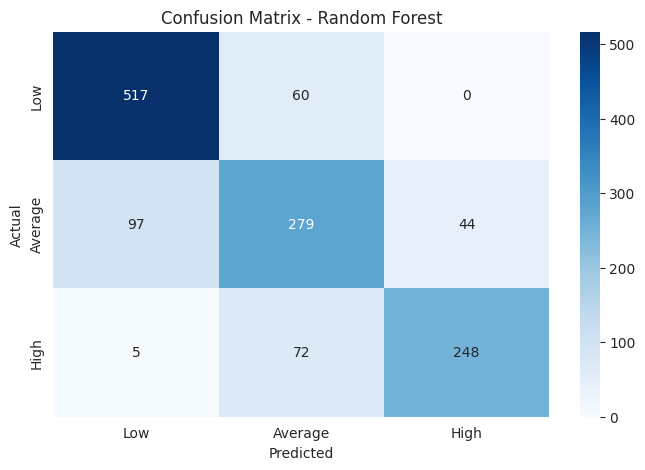

In [ ]:
cm = confusion_matrix(y_test_c, preds, labels=["Low", "Average", "High"])
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Average", "High"], yticklabels=["Low", "Average", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.show()

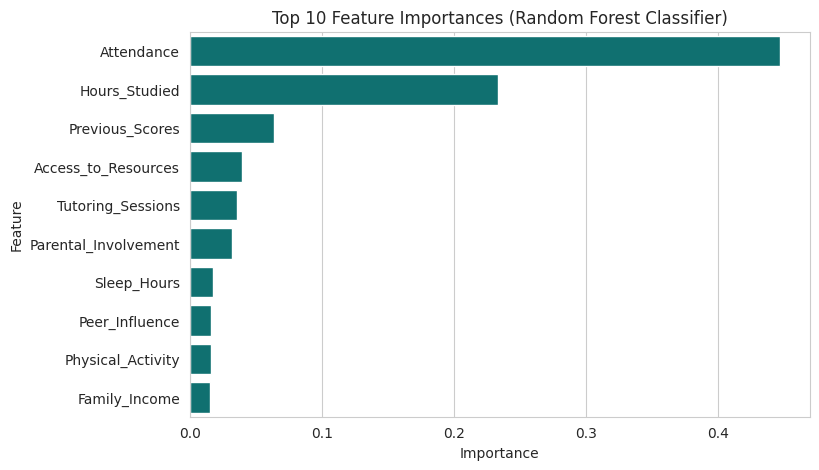

In [ ]:
importances = pd.Series(fitted_clfs["Random Forest"].feature_importances_, index=features)
importances = importances.sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=importances.values, y=importances.index, color="teal")
plt.title("Top 10 Feature Importances (Random Forest Classifier)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Attendance, Hours_Studied and Previous_Scores consistently come out on top across both the regression and classification models, which lines up with what the EDA showed earlier.

## Module 4: Performance Dashboard

A full interactive dashboard is built separately with Streamlit (`dashboard.py`, included alongside this notebook) so it can be run locally or deployed to Streamlit Cloud. It lets a user pick a student and see their predicted score, how they compare to the class, and their personalized recommendations.

Below is a static preview of the same information, built with the test set from this notebook.

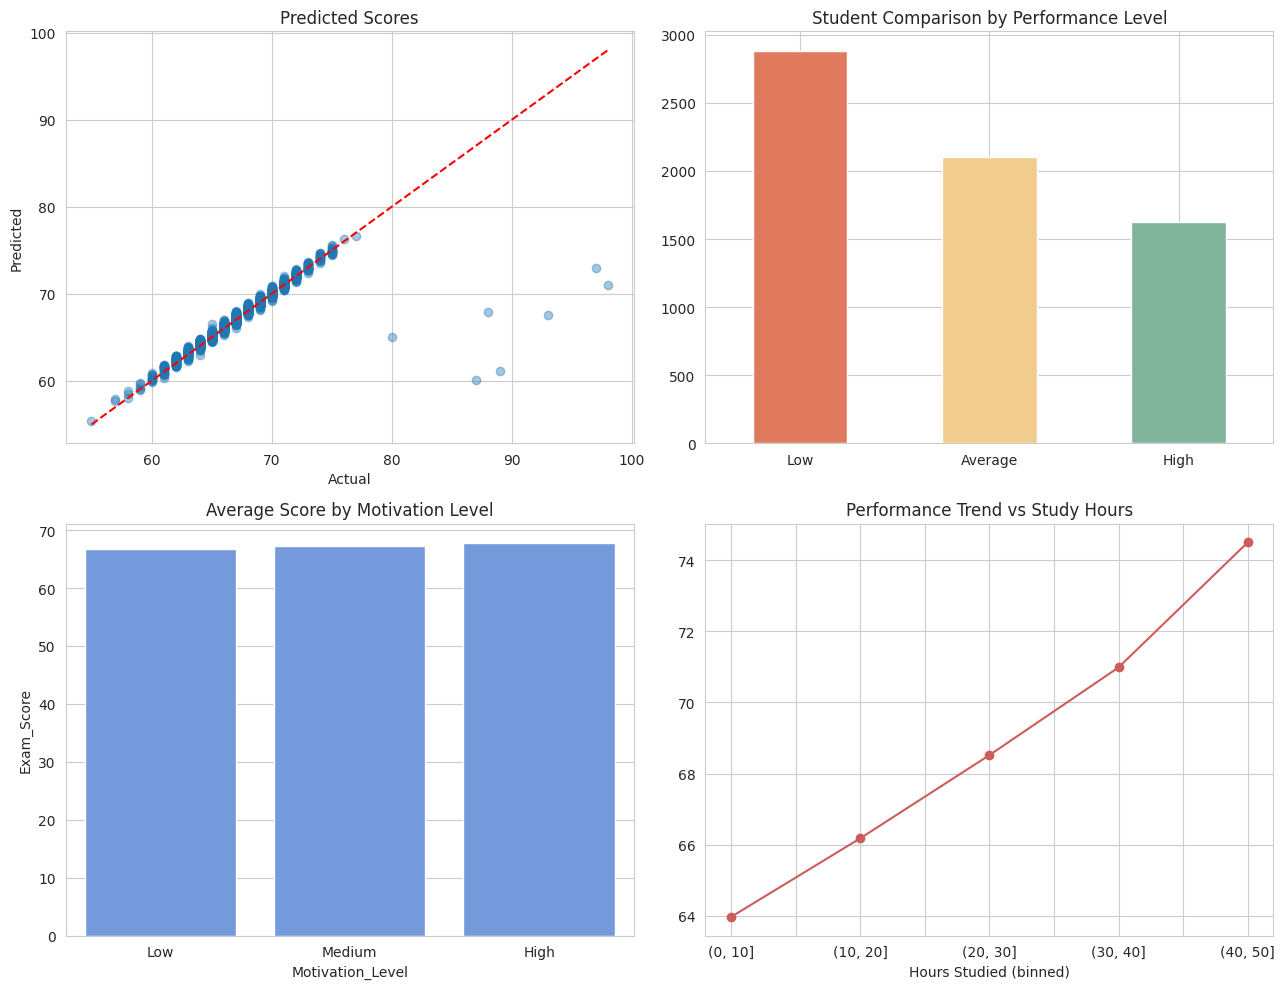

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Predicted vs actual scores
axes[0, 0].scatter(y_test, best_reg_model.predict(X_test), alpha=0.4)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0, 0].set_title("Predicted Scores")
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")

# Performance level breakdown
df["Performance_Level"].value_counts().reindex(["Low", "Average", "High"]).plot(
    kind="bar", ax=axes[0, 1], color=["#e07a5f", "#f2cc8f", "#81b29a"])
axes[0, 1].set_title("Student Comparison by Performance Level")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=0)

# Factor-wise analysis
sns.barplot(data=df_eda, x="Motivation_Level", y="Exam_Score", order=["Low", "Medium", "High"],
            errorbar=None, ax=axes[1, 0], color="cornflowerblue")
axes[1, 0].set_title("Average Score by Motivation Level")

# Performance trend across study hours (binned)
study_bins = pd.cut(df_eda["Hours_Studied"], bins=[0, 10, 20, 30, 40, 50])
df_eda.groupby(study_bins, observed=True)["Exam_Score"].mean().plot(
    kind="line", marker="o", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Performance Trend vs Study Hours")
axes[1, 1].set_xlabel("Hours Studied (binned)")

plt.tight_layout()
plt.show()

## Module 5: Recommendation System

A simple rule-based engine that looks at a student's weak spots and generates the same kind of suggestions a mentor would give — no ML needed here, just thresholds derived from the EDA above (dataset medians as the "healthy" baseline).

In [ ]:
medians = df_eda[["Hours_Studied", "Attendance", "Sleep_Hours", "Tutoring_Sessions"]].median()
medians

Hours_Studied        20.0
Attendance           80.0
Sleep_Hours           7.0
Tutoring_Sessions     1.0
dtype: float64

In [ ]:
def generate_recommendations(student):
    tips = []

    if student["Hours_Studied"] < medians["Hours_Studied"]:
        tips.append("Increase weekly study hours - currently below the class median.")

    if student["Attendance"] < medians["Attendance"]:
        tips.append("Improve class attendance to stay on top of coursework.")

    if student["Previous_Scores"] < df_eda["Previous_Scores"].median():
        tips.append("Focus on revising foundational topics - previous scores are below average.")

    if student["Tutoring_Sessions"] < medians["Tutoring_Sessions"]:
        tips.append("Attend more tutoring/practice sessions for extra support.")

    if student["Sleep_Hours"] < 6:
        tips.append("Aim for more consistent sleep - it's currently on the lower side.")

    if student["Motivation_Level"] == "Low":
        tips.append("Set smaller, achievable goals to help build study motivation.")

    if not tips:
        tips.append("Keep up the current routine - performance indicators look healthy.")

    return tips

In [ ]:
# Try it out on the five lowest scorers in the dataset
sample_students = df_eda.nsmallest(5, "Exam_Score")

for idx, student in sample_students.iterrows():
    print(f"Student {idx} - Exam Score: {student['Exam_Score']}")
    for tip in generate_recommendations(student):
        print("  -", tip)
    print()

Student 1101 - Exam Score: 55
  - Increase weekly study hours - currently below the class median.
  - Improve class attendance to stay on top of coursework.
  - Focus on revising foundational topics - previous scores are below average.

Student 5507 - Exam Score: 56
  - Increase weekly study hours - currently below the class median.
  - Improve class attendance to stay on top of coursework.
  - Focus on revising foundational topics - previous scores are below average.
  - Attend more tutoring/practice sessions for extra support.

Student 2880 - Exam Score: 57
  - Increase weekly study hours - currently below the class median.
  - Improve class attendance to stay on top of coursework.
  - Focus on revising foundational topics - previous scores are below average.
  - Attend more tutoring/practice sessions for extra support.

Student 3543 - Exam Score: 57
  - Increase weekly study hours - currently below the class median.
  - Improve class attendance to stay on top of coursework.
  - Focu

## Conclusion

- Cleaned the dataset (no duplicates, missing categorical values imputed with the mode) and prepared it for modeling with ordinal encoding and feature scaling.
- EDA confirmed attendance, study hours and previous scores as the strongest drivers of exam performance.
- For predicting the exact score, plain Linear Regression actually won out (R2 ~0.77) over the tree-based models - the relationship between the features and Exam_Score is close to linear, so the extra complexity of Decision Tree/Random Forest didn't help and slightly overfit. For the Low/Average/High classification task, Random Forest performed best (~79% accuracy), which lines up with the feature importance chart above.
- Added a rule-based recommendation engine and a static dashboard preview; the full interactive version lives in `dashboard.py`.

**Possible next steps:** hyperparameter tuning (GridSearchCV), trying gradient boosting models, and collecting subject-wise marks if the dataset is extended in the future.